In [906]:
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import re

# Configuration

In [907]:
data_dir = Path("../data")
figure_dir = Path("../figures_paper")

# This script applies mapping twice. First to PyPSA carriers and later to ENTSO-E data. This gives the common names.
# This is the "nice names"
mapping_pypsa_carriers = {
    "Combined-Cycle Gas": "Gas",
    "Load shedding": None,
    "Offshore Wind (AC)": "Wind Offshore",
    "Offshore Wind (DC)": "Wind Offshore",
    "Onshore Wind": "Wind Onshore",
    "Open-Cycle Gas": "Gas",
    "Run of River": "Run-of-river",
    "Solar": "Solar",
    "biomass": "Biomass",
    "nuclear": "Nuclear",
    "coal": "Coal",
    "lignite": "Lignite",
    "oil": "Oil",
    "solar-hsat": "Solar",
    "Pumped Hydro Storage": "Pumped Hydro Storage",
    "Reservoir & Dam": "Reservoir & Dam",
    "geothermal": "Geothermal"
}

start_date = (pd.Timestamp("2022-01-01"),)
end_date = (pd.Timestamp("2022-12-31 23:00"),)


country = "DE"

resampling_rule = "W-MON"  # Weekly, starting on Monday

x_length = 6

phi = 1.618

data_dir = Path("../data")

n = pypsa.Network(data_dir / "network_files" / "hindcast-dyn-rolling-wy2022.nc")

INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [908]:
n.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
name,,,,,
DC,0.0000,#8a1caf,DC,inf,0.0
AC,0.0000,#70af1d,AC,inf,0.0
geothermal,0.1200,#ba91b1,geothermal,inf,0.0
nuclear,0.0000,#ff8c00,nuclear,inf,0.0
biomass,0.0000,#baa741,biomass,inf,0.0
lignite,0.4069,#826837,lignite,inf,0.0
CCGT,0.1980,#a85522,Combined-Cycle Gas,inf,0.0
coal,0.3361,#545454,coal,inf,0.0
OCGT,0.1980,#e0986c,Open-Cycle Gas,inf,0.0


In [909]:
# Color mapping for plotting

color_dict = n.carriers["color"].to_dict()

mapping_color = {
    "offwind-ac": "Wind Offshore",
    "offwind-dc": "Wind Offshore",
    "onwind": "Wind Onshore",
    "solar": "Solar",
    "solar-hsat": "Solar",
    "CCGT": "Gas",
    "OCGT": "Gas",
    "PHS": "Pumped Hydro Storage",
    "biomass": "Biomass",
    "coal": "Coal",
    "geothermal": "Geothermal",
    "hydro": "Reservoir & Dam",
    "lignite": "Lignite",
    "nuclear": "Nuclear",
    "oil": "Oil",
    "ror": "Run-of-river",
}

color_dict_new = {}

for original_name, new_name in mapping_color.items():
    # Use the color from the original carrier
    if original_name in color_dict:
        color_dict_new[new_name] = color_dict[original_name]


color_dict_new['Other'] = 'tab:red'
color_dict_new

{'Wind Offshore': '#74c6f2',
 'Wind Onshore': '#235ebc',
 'Solar': '#fdb915',
 'Gas': '#e0986c',
 'Pumped Hydro Storage': '#51dbcc',
 'Biomass': '#baa741',
 'Coal': '#545454',
 'Geothermal': '#ba91b1',
 'Reservoir & Dam': '#298c81',
 'Lignite': '#826837',
 'Nuclear': '#ff8c00',
 'Oil': '#c9c9c9',
 'Run-of-river': '#3dbfb0',
 'Other': 'tab:red'}

# PyPSA generation plot

In [910]:
supply_stats = n.statistics.supply(groupby=["bus", "carrier"], groupby_time=False) / 1000
country_supply = supply_stats.xs(country, level="bus")
country_generators_and_storage = country_supply.loc[["Generator", "StorageUnit"], :]
country_dispatch_raw = country_generators_and_storage.T.droplevel(0, axis=1)

ignored_carriers = [
    col for col, target in mapping_pypsa_carriers.items() if target is None and col in country_dispatch_raw.columns
]
country_dispatch_raw = country_dispatch_raw.drop(columns=ignored_carriers)

carrier_rename = {
    col: target
    for col, target in mapping_pypsa_carriers.items()
    if target is not None and col in country_dispatch_raw.columns
}
country_dispatch = country_dispatch_raw.rename(columns=carrier_rename)
country_dispatch = country_dispatch.T.groupby(level=0).sum().T  # merg


if resampling_rule:
    country_dispatch_res = country_dispatch.resample(resampling_rule).sum()
else:
    country_dispatch_res = country_dispatch

country_dispatch_res.head()

carrier,Biomass,Coal,Gas,Lignite,Oil,Pumped Hydro Storage,Run-of-river,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,
2022-01-03,107.616933,725.161570,0.000059,1559.697872,0.000020,0.000004,152.273746,146.318946,488.846932,2398.695149
2022-01-10,251.106185,3005.769811,407.167121,3645.892577,0.000272,71.322251,537.467972,392.912739,918.130585,3538.653694
2022-01-17,251.106201,3039.421621,1218.821150,3645.892804,0.000054,24.556646,518.176179,413.602077,880.398025,2551.833977
2022-01-24,251.106206,3035.350240,1463.503808,3645.892824,0.000000,6.474318,544.699041,381.930869,893.374217,2766.826650
2022-01-31,251.106206,2520.201307,515.585640,3641.845074,0.000000,56.391855,543.074468,375.607730,992.310579,5014.369174


In [911]:
withdrawal_stats = n.statistics.withdrawal(groupby=["bus", "carrier"], groupby_time=False) / 1000 # Converted to GWh
country_withdrawal = withdrawal_stats.xs(country, level="bus")
country_generators_and_storage = country_withdrawal.loc[["Generator", "StorageUnit"], :]
country_consumption_raw = country_generators_and_storage.T.droplevel(0, axis=1)

carrier_rename = {
    col: target
    for col, target in mapping_pypsa_carriers.items()
    if target is not None and col in country_consumption_raw.columns
}
country_consumption = country_consumption_raw.rename(columns=carrier_rename)
country_consumption = country_consumption.T.groupby(level=0).sum().T  # merg


keek_withdrawal = ["Pumped Hydro Storage"]
# Drop all other columns except the ones in keek_withdrawal
country_consumption_clean = country_consumption[keek_withdrawal]
country_consumption_clean


if resampling_rule:
    country_consumption_res = country_consumption_clean.resample(resampling_rule).sum()
else:
    country_consumption_res = country_consumption_clean

country_consumption_res.head()

carrier,Pumped Hydro Storage
snapshot,
2022-01-03,41.374444
2022-01-10,64.650352
2022-01-17,41.374572
2022-01-24,41.374571
2022-01-31,71.678982


In [912]:
country_consumption_res["Pumped Hydro Storage"] 

snapshot
2022-01-03    4.137444e+01
2022-01-10    6.465035e+01
2022-01-17    4.137457e+01
2022-01-24    4.137457e+01
2022-01-31    7.167898e+01
2022-02-07    3.510200e+00
2022-02-14    6.506000e-05
2022-02-21    4.137475e+01
2022-02-28    8.274914e+01
2022-03-07    2.411043e+01
2022-03-14    1.024666e+02
2022-03-21    4.137457e+01
2022-03-28    0.000000e+00
2022-04-04    3.964971e+01
2022-04-11    1.363653e+01
2022-04-18    2.071683e+01
2022-04-25    1.863466e+00
2022-05-02    3.519000e-05
2022-05-09    1.499000e-05
2022-05-16    5.557155e+00
2022-05-23    1.496209e+01
2022-05-30    1.236305e+02
2022-06-06    0.000000e+00
2022-06-13    3.816329e+01
2022-06-20    4.137457e+01
2022-06-27    2.963674e+01
2022-07-04    4.137457e+01
2022-07-11    1.565264e+01
2022-07-18    4.883310e+01
2022-07-25    1.071868e+02
2022-08-01    5.269419e+01
2022-08-08    2.180844e+02
2022-08-15    2.229931e+02
2022-08-22    1.597575e+02
2022-08-29    1.808843e+02
2022-09-05    1.267246e+02
2022-09-12    2.065

In [913]:
country_dispatch_res["Pumped Hydro Storage"] 

snapshot
2022-01-03    3.960000e-06
2022-01-10    7.132225e+01
2022-01-17    2.455665e+01
2022-01-24    6.474318e+00
2022-01-31    5.639186e+01
2022-02-07    0.000000e+00
2022-02-14    2.354100e-04
2022-02-21    6.690000e-06
2022-02-28    6.206186e+01
2022-03-07    4.529423e+01
2022-03-14    4.963853e+01
2022-03-21    3.103093e+01
2022-03-28    3.103093e+01
2022-04-04    4.759164e+01
2022-04-11    7.219256e+00
2022-04-18    2.576502e+01
2022-04-25    6.160000e-06
2022-05-02    1.397697e+00
2022-05-09    8.044388e+00
2022-05-16    1.816500e-04
2022-05-23    3.103053e+01
2022-05-30    6.169198e+01
2022-06-06    3.103093e+01
2022-06-13    0.000000e+00
2022-06-20    3.103093e+01
2022-06-27    2.222756e+01
2022-07-04    1.855118e+01
2022-07-11    1.370896e+01
2022-07-18    4.896937e+01
2022-07-25    6.845581e+01
2022-08-01    6.516839e+01
2022-08-08    1.413481e+02
2022-08-15    1.668540e+02
2022-08-22    1.297457e+02
2022-08-29    1.257341e+02
2022-09-05    1.013600e+02
2022-09-12    1.537

In [914]:
country_dispatch_res.index

DatetimeIndex(['2022-01-03', '2022-01-10', '2022-01-17', '2022-01-24',
               '2022-01-31', '2022-02-07', '2022-02-14', '2022-02-21',
               '2022-02-28', '2022-03-07', '2022-03-14', '2022-03-21',
               '2022-03-28', '2022-04-04', '2022-04-11', '2022-04-18',
               '2022-04-25', '2022-05-02', '2022-05-09', '2022-05-16',
               '2022-05-23', '2022-05-30', '2022-06-06', '2022-06-13',
               '2022-06-20', '2022-06-27', '2022-07-04', '2022-07-11',
               '2022-07-18', '2022-07-25', '2022-08-01', '2022-08-08',
               '2022-08-15', '2022-08-22', '2022-08-29', '2022-09-05',
               '2022-09-12', '2022-09-19', '2022-09-26', '2022-10-03',
               '2022-10-10', '2022-10-17', '2022-10-24', '2022-10-31',
               '2022-11-07', '2022-11-14', '2022-11-21', '2022-11-28',
               '2022-12-05', '2022-12-12', '2022-12-19', '2022-12-26',
               '2023-01-02'],
              dtype='datetime64[ns]', name='sna

In [915]:
country_dispatch.sum()

carrier
Biomass                  13091.942908
Coal                    116544.352033
Gas                       9682.478614
Lignite                 181111.516473
Oil                       4888.401077
Pumped Hydro Storage      2458.050208
Run-of-river             17282.147658
Solar                    70218.755179
Wind Offshore            34954.213130
Wind Onshore            116544.432649
dtype: float64

# ENTSOE

In [916]:
entsoe_raw = pd.read_csv(
    data_dir / "generation" / f"generation_{country}_hourly_data.csv",
    index_col=0,
    parse_dates=True,
)

entsoe_filtered_raw = entsoe_raw[pd.Timestamp(start_date[0], tz="UTC") : pd.Timestamp(end_date[0], tz="UTC")]

entsoe_filtered_raw.head()

,"('Biomass', 'Actual Aggregated')","('Fossil Brown coal/Lignite', 'Actual Aggregated')","('Fossil Coal-derived gas', 'Actual Aggregated')","('Fossil Gas', 'Actual Aggregated')","('Fossil Gas', 'Actual Consumption')","('Fossil Hard coal', 'Actual Aggregated')","('Fossil Oil', 'Actual Aggregated')","('Fossil Oil', 'Actual Consumption')","('Geothermal', 'Actual Aggregated')","('Hydro Pumped Storage', 'Actual Aggregated')",...,"('Other', 'Actual Aggregated')","('Other renewable', 'Actual Aggregated')","('Other renewable', 'Actual Consumption')","('Solar', 'Actual Aggregated')","('Solar', 'Actual Consumption')","('Waste', 'Actual Aggregated')","('Wind Offshore', 'Actual Aggregated')","('Wind Onshore', 'Actual Aggregated')","('Wind Onshore', 'Actual Consumption')",Biomass
2022-01-01 00:00:00+00:00,4253.333333,3540.666667,NaN,3414.333333,NaN,2048.666667,279.0,NaN,26.0,402.00,...,333.0,132.0,NaN,2.0,0.0,851.333333,5804.333333,24166.00,0.0,NaN
2022-01-01 01:00:00+00:00,4258.000000,3495.000000,NaN,3408.750000,NaN,2033.250000,279.0,NaN,26.0,379.75,...,333.0,133.0,NaN,2.0,0.0,845.250000,5548.000000,23188.75,0.0,NaN
2022-01-01 02:00:00+00:00,4263.000000,3504.750000,NaN,3414.000000,NaN,2023.750000,279.0,NaN,27.0,321.25,...,333.0,132.5,NaN,2.0,0.0,841.750000,5382.750000,22113.50,0.0,NaN
2022-01-01 03:00:00+00:00,4267.250000,3537.500000,NaN,3428.750000,NaN,2013.250000,279.0,NaN,27.0,244.25,...,333.0,131.5,NaN,2.0,0.0,835.500000,5586.500000,20620.75,0.0,NaN
2022-01-01 04:00:00+00:00,4280.250000,3767.000000,NaN,3421.250000,NaN,2014.000000,279.0,NaN,27.0,212.75,...,333.0,131.5,NaN,2.0,0.0,841.750000,4531.250000,19587.75,0.0,NaN


In [917]:
print(entsoe_filtered_raw)


                           ('Biomass', 'Actual Aggregated')  \
2022-01-01 00:00:00+00:00                       4253.333333   
2022-01-01 01:00:00+00:00                       4258.000000   
2022-01-01 02:00:00+00:00                       4263.000000   
2022-01-01 03:00:00+00:00                       4267.250000   
2022-01-01 04:00:00+00:00                       4280.250000   
...                                                     ...   
2022-12-31 19:00:00+00:00                       4362.750000   
2022-12-31 20:00:00+00:00                       4239.750000   
2022-12-31 21:00:00+00:00                       4176.750000   
2022-12-31 22:00:00+00:00                       4140.750000   
2022-12-31 23:00:00+00:00                       4044.500000   

                           ('Fossil Brown coal/Lignite', 'Actual Aggregated')  \
2022-01-01 00:00:00+00:00                                        3540.666667    
2022-01-01 01:00:00+00:00                                        3495.000000    


In [918]:
#Mapping depend on entso-e reporting
if "Actual Aggregated" in str(entsoe_filtered_raw.columns):
    print("agg")
    keep_cols = [
        "('Biomass', 'Actual Aggregated')",
        "('Fossil Brown coal/Lignite', 'Actual Aggregated')",
        "('Fossil Coal-derived gas', 'Actual Aggregated')",
        "('Fossil Gas', 'Actual Aggregated')",
        "('Fossil Hard coal', 'Actual Aggregated')",
        "('Fossil Oil', 'Actual Aggregated')",
        "('Geothermal', 'Actual Aggregated')",
        "('Hydro Pumped Storage', 'Actual Aggregated')",
        #"('Hydro Pumped Storage', 'Actual Consumption')",
        "('Hydro Run-of-river and poundage', 'Actual Aggregated')",
        "('Hydro Water Reservoir', 'Actual Aggregated')",
        "('Nuclear', 'Actual Aggregated')",
        "('Other', 'Actual Aggregated')",
        "('Other renewable', 'Actual Aggregated')",
        "('Solar', 'Actual Aggregated')",
        "('Waste', 'Actual Aggregated')",
        "('Wind Offshore', 'Actual Aggregated')",
        "('Wind Onshore', 'Actual Aggregated')",
    ]
    


    keep_cols_existing = [c for c in keep_cols if c in entsoe_filtered_raw.columns]

    other_cols = [c for c in entsoe_filtered_raw.columns if "(" not in c]

    final_cols = list(set(keep_cols_existing + other_cols))

    entsoe_filtered = entsoe_filtered_raw[final_cols].copy()
    entsoe_filtered = entsoe_filtered.drop(columns=["Energy storage"], errors="ignore")
   

    mapping_entsoe_pypsa = {
        "('Biomass', 'Actual Aggregated')": "Biomass",
        "('Fossil Brown coal/Lignite', 'Actual Aggregated')": "Lignite",
        "('Fossil Coal-derived gas', 'Actual Aggregated')": "Gas",
        "('Fossil Gas', 'Actual Aggregated')": "Gas",
        "('Fossil Hard coal', 'Actual Aggregated')": "Coal",
        "('Fossil Oil', 'Actual Aggregated')": "Oil",
        "('Geothermal', 'Actual Aggregated')": "Geothermal",
        "('Hydro Pumped Storage', 'Actual Aggregated')": "Pumped Hydro Storage",
        #"('Hydro Pumped Storage', 'Actual Consumption')": ,
        "('Hydro Run-of-river and poundage', 'Actual Aggregated')": "Run-of-river",
        "('Hydro Water Reservoir', 'Actual Aggregated')": "Reservoir & Dam",
        "('Nuclear', 'Actual Aggregated')": "Nuclear",
        "('Other', 'Actual Aggregated')": "Other",
        "('Other renewable', 'Actual Aggregated')": "Other",
        "('Solar', 'Actual Aggregated')": "Solar",
        "('Waste', 'Actual Aggregated')": "Biomass",
        "('Wind Offshore', 'Actual Aggregated')": "Wind Offshore",
        "('Wind Onshore', 'Actual Aggregated')": "Wind Onshore",
    }

    entsoe_clean = (entsoe_filtered.rename(columns=mapping_entsoe_pypsa) /1000).copy() # convert to GWh
    entsoe_clean = entsoe_clean.T.groupby(level=0).sum().T




else:
    print("else")
    mapping_entsoe_pypsa = {
    "Biomass": "Biomass",
    "Fossil Brown coal/Lignite": "Lignite",
    "Fossil Coal-derived gas": "Gas",
    "Fossil Gas": "Gas",
    "Fossil Hard coal": "Coal",
    "Fossil Oil": "Oil",
    "Fossil Oil shale": "Oil",
    "Fossil Peat": "Lignite",
    "Geothermal": "Geothermal",
    "Hydro Pumped Storage Net": "Pumped Hydro Storage",
    "Hydro Run-of-river and poundage": "Run-of-river",
    "Hydro Water Reservoir": "Reservoir & Dam",
    "Marine": "Other",
    "Nuclear": "Nuclear",
    "Other": "Other",
    "Other renewable": "Other",
    "Solar": "Solar",
    "Waste": "Biomass",
    "Wind Offshore": "Wind Offshore",
    "Wind Onshore": "Wind Onshore",
}

       
    entsoe_filtered = entsoe_filtered_raw.rename(columns=mapping_entsoe_pypsa) 
    entsoe_filtered = entsoe_filtered.drop(columns=["Energy storage"], errors="ignore")
    entsoe_clean = (entsoe_filtered.T.groupby(level=0).sum().T)/1000 # convert to GWh
    

print(entsoe_clean)



agg
                            Biomass      Coal       Gas  Geothermal   Lignite  \
2022-01-01 00:00:00+00:00  5.104667  2.048667  3.414333     0.02600  3.540667   
2022-01-01 01:00:00+00:00  5.103250  2.033250  3.408750     0.02600  3.495000   
2022-01-01 02:00:00+00:00  5.104750  2.023750  3.414000     0.02700  3.504750   
2022-01-01 03:00:00+00:00  5.102750  2.013250  3.428750     0.02700  3.537500   
2022-01-01 04:00:00+00:00  5.122000  2.014000  3.421250     0.02700  3.767000   
...                             ...       ...       ...         ...       ...   
2022-12-31 19:00:00+00:00  5.110250  2.197000  2.150250     0.02400  3.761750   
2022-12-31 20:00:00+00:00  4.991250  2.217500  2.153000     0.02400  3.767000   
2022-12-31 21:00:00+00:00  4.921500  2.216750  2.153250     0.02425  3.760500   
2022-12-31 22:00:00+00:00  4.890750  2.202500  2.123750     0.02500  3.814750   
2022-12-31 23:00:00+00:00  4.792250  2.067500  2.246000     0.02525  3.859250   

                       

In [919]:
#Additional mapping required for contries that report in mixed formes
mapping_entsoe_pypsa = {
    "Biomass": "Biomass",
    "Fossil Brown coal/Lignite": "Lignite",
    "Fossil Coal-derived gas": "Gas",
    "Fossil Gas": "Gas",
    "Fossil Hard coal": "Coal",
    "Fossil Oil": "Oil",
    "Fossil Oil shale": "Oil",
    "Fossil Peat": "Lignite",
    "Geothermal": "Geothermal",
    "Hydro Pumped Storage Net": "Pumped Hydro Storage",
    "Hydro Pumped Storage": "Pumped Hydro Storage",
    "Hydro Run-of-river and poundage": "Run-of-river",
    "Hydro Water Reservoir": "Reservoir & Dam",
    "Marine": "Other",
    "Nuclear": "Nuclear",
    "Other": "Other",
    "Other renewable": "Other",
    "Solar": "Solar",
    "Waste": "Biomass",
    "Wind Offshore": "Wind Offshore",
    "Wind Onshore": "Wind Onshore",
    }

mapping_existing = {k: v for k, v in mapping_entsoe_pypsa.items() if k in entsoe_clean.columns}

entsoe_filtered_v2 = entsoe_clean.rename(columns=mapping_existing).copy()





print(entsoe_filtered_v2)

                            Biomass      Coal       Gas  Geothermal   Lignite  \
2022-01-01 00:00:00+00:00  5.104667  2.048667  3.414333     0.02600  3.540667   
2022-01-01 01:00:00+00:00  5.103250  2.033250  3.408750     0.02600  3.495000   
2022-01-01 02:00:00+00:00  5.104750  2.023750  3.414000     0.02700  3.504750   
2022-01-01 03:00:00+00:00  5.102750  2.013250  3.428750     0.02700  3.537500   
2022-01-01 04:00:00+00:00  5.122000  2.014000  3.421250     0.02700  3.767000   
...                             ...       ...       ...         ...       ...   
2022-12-31 19:00:00+00:00  5.110250  2.197000  2.150250     0.02400  3.761750   
2022-12-31 20:00:00+00:00  4.991250  2.217500  2.153000     0.02400  3.767000   
2022-12-31 21:00:00+00:00  4.921500  2.216750  2.153250     0.02425  3.760500   
2022-12-31 22:00:00+00:00  4.890750  2.202500  2.123750     0.02500  3.814750   
2022-12-31 23:00:00+00:00  4.792250  2.067500  2.246000     0.02525  3.859250   

                           

In [920]:
entsoe_clean = entsoe_filtered_v2.T.groupby(level=0).sum().T.copy()


In [921]:
entsoe_clean.sum()

Biomass                  44540.633917
Coal                     62895.387417
Gas                      45912.245083
Geothermal                 203.240000
Lignite                 103525.878167
Nuclear                  32823.623250
Oil                       2788.978500
Other                     3390.903500
Pumped Hydro Storage     10155.941250
Reservoir & Dam           1556.329417
Run-of-river             11305.329083
Solar                    55987.627750
Wind Offshore            24746.794333
Wind Onshore            101296.347750
dtype: float64

In [922]:
# Test how ENTSO-E reports 
agg_col = "('Hydro Pumped Storage', 'Actual Aggregated')"
cons_col = "('Hydro Pumped Storage', 'Actual Consumption')"
net_col = "Hydro Pumped Storage Net"
base_col = "Hydro Pumped Storage"

if agg_col in entsoe_filtered_raw.columns and cons_col in entsoe_filtered_raw.columns and entsoe_filtered_raw["('Hydro Pumped Storage', 'Actual Aggregated')"].sum()>0:
    print("agg")
    # Calculate the net dispatch for Pumped Hydro Storage
    #country_dispatch_res["Pumped Hydro Storage"] = country_dispatch_res["Pumped Hydro Storage"] - country_consumption_res["Pumped Hydro Storage"]
    # Clip all negative values to zero (since we are only interested in the dispatch, not the consumption)
    #country_dispatch_res["Pumped Hydro Storage"] = country_dispatch_res["Pumped Hydro Storage"].clip(lower=0)
    country_dispatch["Pumped Hydro Storage"] = country_dispatch["Pumped Hydro Storage"].clip(lower=0)
    entsoe_clean["Pumped Hydro Storage"]=entsoe_clean["Pumped Hydro Storage"].clip(lower=0)
elif net_col in entsoe_filtered_raw.columns:
    # Calculate the net dispatch for Pumped Hydro Storage
    #country_dispatch_res["Pumped Hydro Storage"] = country_dispatch_res["Pumped Hydro Storage"] - country_consumption_res["Pumped Hydro Storage"]
    country_dispatch["Pumped Hydro Storage"] = country_dispatch["Pumped Hydro Storage"] - country_consumption["Pumped Hydro Storage"]
    # Clip all negative values to zero (since we are only interested in the dispatch, not the consumption)
    country_dispatch["Pumped Hydro Storage"] = country_dispatch["Pumped Hydro Storage"].clip(lower=0)
    entsoe_clean["Pumped Hydro Storage"]=entsoe_clean["Pumped Hydro Storage"].clip(lower=0)
    print("net")
elif base_col in entsoe_filtered_raw.columns:
    print("base")
    # Calculate the net dispatch for Pumped Hydro Storage
    #country_dispatch_res["Pumped Hydro Storage"] = country_dispatch_res["Pumped Hydro Storage"] - country_consumption_res["Pumped Hydro Storage"]
    # Clip all negative values to zero (since we are only interested in the dispatch, not the consumption)
    #country_dispatch_res["Pumped Hydro Storage"] = country_dispatch_res["Pumped Hydro Storage"].clip(lower=0)
    country_dispatch["Pumped Hydro Storage"] = country_dispatch["Pumped Hydro Storage"].clip(lower=0)
    entsoe_clean["Pumped Hydro Storage"]=entsoe_clean["Pumped Hydro Storage"].clip(lower=0)

agg


In [923]:
entsoe_clean = entsoe_clean.tz_localize(None)
entsoe_clean.index

DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 01:00:00',
               '2022-01-01 02:00:00', '2022-01-01 03:00:00',
               '2022-01-01 04:00:00', '2022-01-01 05:00:00',
               '2022-01-01 06:00:00', '2022-01-01 07:00:00',
               '2022-01-01 08:00:00', '2022-01-01 09:00:00',
               ...
               '2022-12-31 14:00:00', '2022-12-31 15:00:00',
               '2022-12-31 16:00:00', '2022-12-31 17:00:00',
               '2022-12-31 18:00:00', '2022-12-31 19:00:00',
               '2022-12-31 20:00:00', '2022-12-31 21:00:00',
               '2022-12-31 22:00:00', '2022-12-31 23:00:00'],
              dtype='datetime64[us]', length=8760, freq=None)

In [924]:
#entsoe_clean = entsoe_clean.T.groupby(level=0).sum().T
entsoe_clean.head()

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,5.104667,2.048667,3.414333,0.026,3.540667,3.34700,0.279,0.4650,0.40200,0.088667,1.429333,0.002,5.804333,24.16600
2022-01-01 01:00:00,5.103250,2.033250,3.408750,0.026,3.495000,3.34425,0.279,0.4660,0.37975,0.046750,1.428250,0.002,5.548000,23.18875
2022-01-01 02:00:00,5.104750,2.023750,3.414000,0.027,3.504750,3.34250,0.279,0.4655,0.32125,0.031500,1.428250,0.002,5.382750,22.11350
2022-01-01 03:00:00,5.102750,2.013250,3.428750,0.027,3.537500,3.34250,0.279,0.4645,0.24425,0.078500,1.426500,0.002,5.586500,20.62075
2022-01-01 04:00:00,5.122000,2.014000,3.421250,0.027,3.767000,3.34725,0.279,0.4645,0.21275,0.065750,1.419750,0.002,4.531250,19.58775


In [925]:
country_dispatch.head()

carrier,Biomass,Coal,Gas,Lignite,Oil,Pumped Hydro Storage,Run-of-river,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,
2022-01-01 00:00:00,1.49468,2.960343,8.100000e-07,21.701735,2.700000e-07,0.0,1.983777,0.0,7.274166,30.987607
2022-01-01 01:00:00,1.49468,2.659769,8.300000e-07,21.701735,2.700000e-07,0.0,1.986250,0.0,7.273037,29.744282
2022-01-01 02:00:00,1.49468,1.817741,8.300000e-07,21.701735,2.700000e-07,0.0,1.987468,0.0,7.263849,27.809409
2022-01-01 03:00:00,1.49468,1.712104,8.300000e-07,21.701735,2.700000e-07,0.0,1.989163,0.0,7.268351,26.867846
2022-01-01 04:00:00,1.49468,3.594575,8.400000e-07,21.701735,2.700000e-07,0.0,1.990312,0.0,7.273157,24.968361


In [926]:
#common_cols = country_dispatch.columns.intersection(entsoe_clean.columns)

#country_dispatch = country_dispatch[common_cols]
#entsoe_clean = entsoe_clean[common_cols]

In [927]:
unique_cols = list(dict.fromkeys(entsoe_clean.columns.tolist()))
clean_data = {col: entsoe_clean[[col]].sum(axis=1) for col in unique_cols}
entsoe_dedup = pd.DataFrame(clean_data, index=entsoe_clean.index)

diff = entsoe_dedup.copy()
for col in diff.columns:
    if col in country_dispatch.columns:
        diff[col] = entsoe_dedup[col] - country_dispatch[col]
    # else: leave as entsoe value untouched

diff.head()

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,3.609987,-0.911677,3.414333,0.026,-18.161068,3.34700,0.279,0.4650,0.40200,0.088667,-0.554444,0.002,-1.469832,-6.821607
2022-01-01 01:00:00,3.608570,-0.626519,3.408749,0.026,-18.206735,3.34425,0.279,0.4660,0.37975,0.046750,-0.558000,0.002,-1.725037,-6.555532
2022-01-01 02:00:00,3.610070,0.206009,3.413999,0.027,-18.196985,3.34250,0.279,0.4655,0.32125,0.031500,-0.559218,0.002,-1.881099,-5.695909
2022-01-01 03:00:00,3.608070,0.301146,3.428749,0.027,-18.164235,3.34250,0.279,0.4645,0.24425,0.078500,-0.562663,0.002,-1.681851,-6.247096
2022-01-01 04:00:00,3.627320,-1.580575,3.421249,0.027,-17.934735,3.34725,0.279,0.4645,0.21275,0.065750,-0.570562,0.002,-2.741907,-5.380611


In [928]:
diff_res = diff.resample(resampling_rule).sum()
print(diff_res)

               Biomass         Coal          Gas  Geothermal      Lignite  \
2022-01-03  271.987734  -521.466404   286.086774     1.71525 -1147.415455   
2022-01-10  629.765315 -1460.808311   862.965379     4.37750 -1495.896327   
2022-01-17  606.056299 -1246.352621   572.802850     4.56000 -1398.907304   
2022-01-24  632.802044 -1266.465240   322.171442     4.19100 -1439.890824   
2022-01-31  627.038794 -1118.660807  1030.155860     3.75075 -1879.887074   
2022-02-07  634.468051  -685.851333  1023.967507     3.57875 -1919.723013   
2022-02-14  654.855568  -540.978945  1183.357859     4.76500 -1717.717603   
2022-02-21  638.135805   385.379003   948.627055     4.39000 -1909.071033   
2022-02-28  652.519294 -1118.541161  1011.160107     4.39150 -1573.729514   
2022-03-07  674.228794 -1132.301725  1025.280399     4.55300 -1390.582324   
2022-03-14  665.699294 -1164.548738   955.919314     4.36825 -1631.444306   
2022-03-21  661.041294  -772.958713  1198.147872     4.47175 -1417.142600   

# Get prices

In [929]:
prices_dict = {}


sim_labels = {'hindcast-std',
              'hindcast-dyn',
              'hindcast-dyn-rolling'}
# Load simulation
for sim_label in sim_labels:
    file_dir = Path('../results_concat') / sim_label / 'electricity_prices' / "combined_electricity_prices.csv"

    df_sim = pd.read_csv(file_dir, index_col=0, parse_dates=True)
    df_sim = df_sim[df_sim.index.year.isin([2022])]

    prices_dict[sim_label] = df_sim

# Load benchmark
benchmark_path = data_dir / "benchmark" / "electricity_prices.csv"
df_bench = pd.read_csv(benchmark_path, index_col=0, parse_dates=True)

if df_bench.index.tz is None:
     df_bench.index = df_bench.index.tz_localize("UTC")
else:
    df_bench.index = df_bench.index.tz_convert("UTC")

df_bench = df_bench.interpolate().ffill().bfill()

df_bench = df_bench[df_bench.index.year.isin([2022])]

prices_dict["benchmark"] = df_bench
prices_dict

{'hindcast-std':                             AL         AT         BA         BE         BG  \
 snapshot                                                                     
 2022-01-01 00:00:00  72.097260  71.436000  73.612830  66.216301  74.917785   
 2022-01-01 01:00:00  72.097257  68.832655  73.665372  66.216293  74.841815   
 2022-01-01 02:00:00  72.097248  67.375632  73.962119  66.216307  74.635101   
 2022-01-01 03:00:00  72.097249  66.980381  74.254486  66.216307  74.568241   
 2022-01-01 04:00:00  72.097254  66.980869  74.071975  66.216307  74.597178   
 ...                        ...        ...        ...        ...        ...   
 2022-12-31 19:00:00  72.097271  71.855441  74.764514  66.041939  74.917938   
 2022-12-31 20:00:00  72.097268  69.717296  74.110222  63.123865  74.917934   
 2022-12-31 21:00:00  72.097264  69.905726  73.898312  63.109537  74.917929   
 2022-12-31 22:00:00  72.097265  68.930340  73.691826  62.168813  74.917931   
 2022-12-31 23:00:00  72.097265  67.

# That one plot

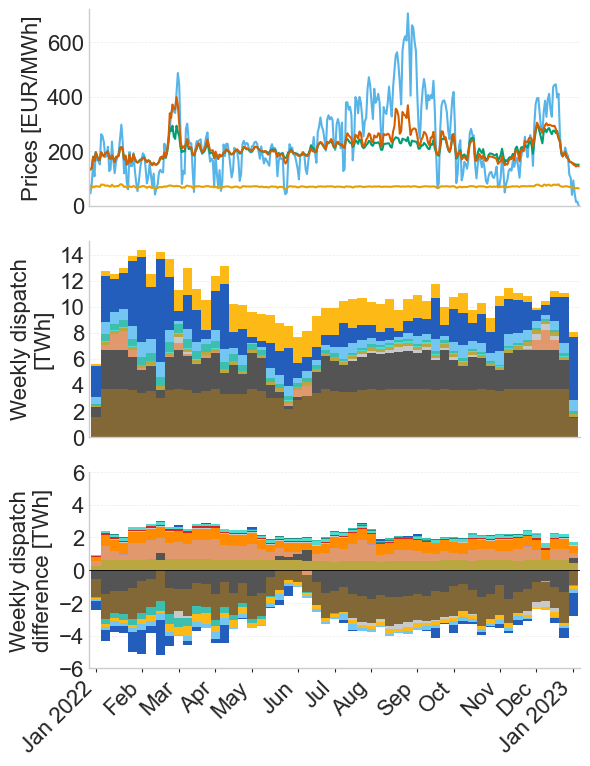

In [930]:
import matplotlib as mpl
# ── Figure ─────────────────────────────────────────────────────────────────────
phi = 1.618
fig, axs = plt.subplots(
    ncols=1,
    nrows=3,
    figsize=(x_length, x_length * phi * 0.8),
    sharex=False,
)

# ── Global style (mirrors setup_style) ────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["axes.spines.right"]   = False
mpl.rcParams["axes.spines.top"]     = False
plt.rcParams["font.family"]         = "Arial"
plt.rcParams["axes.titleweight"]    = "bold"
plt.rcParams["axes.labelsize"]      = 16
plt.rcParams["xtick.labelsize"]     = 16
plt.rcParams["ytick.labelsize"]     = 16
plt.rcParams["legend.fontsize"]     = 16
plt.rcParams["legend.title_fontsize"] = 16

# ── ax[0] : Prices ─────────────────────────────────────────────────────────────
plot_order = [
    "benchmark",
    "hindcast-std",
    "hindcast-dyn",
    "hindcast-dyn-rolling",
]

sim_color = {
    "benchmark":            "#56b4e9",
    "hindcast-dyn":         "#009e73",
    "hindcast-dyn-rolling": "#d55e00",
    "hindcast-std":         "#e69f00",
}

for label in plot_order:
    if label not in prices_dict:
        continue
    df = prices_dict[label]
    if country not in df.columns:
        continue
    series = df[country]
    if resampling_rule:
        series = series.resample("D").mean()
    axs[0].plot(series, label=label, color=sim_color.get(label, None))

axs[0].set_xlim(left=start_date, right=end_date)
axs[0].set_ylim(bottom=0, top=720)
axs[0].set_ylabel("Prices [EUR/MWh]")
axs[0].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[0].xaxis.grid(False)
axs[0].set_axisbelow(True)
axs[0].set_xticks([])
axs[0].tick_params(axis="y", which="both", left=False)

# ── ax[1] : Dispatch ───────────────────────────────────────────────────────────
carrier_order = [
    "Lignite",
    "Nuclear",
    "Coal",
    "Gas",
    "Oil",
    "Biomass",
    "Reservoir & Dam",
    "Pumped Hydro Storage",
    "Run-of-river",
    "Wind Offshore",
    "Wind Onshore",
    "Solar",
]

def reorder_columns(df, order):
    existing  = [c for c in order if c in df.columns]
    remaining = [c for c in df.columns if c not in existing]
    return df[existing + remaining]

country_dispatch_res_twh = reorder_columns(country_dispatch_res, carrier_order) / 1000
country_dispatch_res_twh.plot.bar(
    stacked=True, width=1.0, ax=axs[1], legend=False,
    color=color_dict_new,
)
axs[1].set_ylabel("Weekly dispatch\n[TWh]")
axs[1].set_xlabel("")
axs[1].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[1].xaxis.grid(False)
axs[1].set_axisbelow(True)
axs[1].set_xticks([])
axs[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
axs[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
axs[1].tick_params(axis="y", which="both", left=False)

# ── ax[2] : Dispatch difference ────────────────────────────────────────────────
diff_res_plot = diff_res.copy() / 1000 # Convert to TWh
diff_timestamps = diff_res_plot.index
diff_res_plot = diff_res_plot.reset_index(drop=True)

diff_res_plot.plot.bar(
    stacked=True, width=1.0, ax=axs[2], legend=False,
    color=color_dict_new,
)
axs[2].set_xlabel("")
axs[2].set_ylabel("Weekly dispatch\ndifference [TWh]")
axs[2].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[2].xaxis.grid(False)
axs[2].set_axisbelow(True)
axs[2].set_ylim(bottom=-6, top=6)
axs[2].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
axs[2].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
axs[2].tick_params(axis="y", which="both", left=False)
axs[2].axhline(0, color="black", linewidth=0.6, zorder=3)

# Monthly ticks
tick_positions = []
tick_labels    = []
prev_month     = None
for i, ts in enumerate(diff_timestamps):
    if ts.month != prev_month:
        tick_positions.append(i)
        tick_labels.append(
            ts.strftime("%b %Y") if (ts.month == 1 or prev_month is None)
            else ts.strftime("%b")
        )
        prev_month = ts.month
axs[2].set_xticks(tick_positions)
axs[2].set_xticklabels(tick_labels, rotation=45, ha="right")
axs[2].tick_params(axis="x", length=3)

# ── Shared spine cleanup ────────────────────────────────────────────────────────
for ax in axs:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.tight_layout()
# Save the figure
file_path = figure_dir / f"price_dispatch_comparison_{country}.pdf"
plt.savefig(file_path, bbox_inches="tight")
plt.show()